**Autor**: Juan Alejandro Carrillo Jaimes

**Creación**: 24-08-2026

**Ult Modificación**: 24-08-2026

**Materia**: Mét. Apren Auto para Toma de Decisiones 20262 - A

**Descripción**: Script de aprendizaje supervisado sobre el dataset *Skin
Segmentation* (UCI ID 229, https://archive.ics.uci.edu/dataset/229/skin+segmentation).
Se preparan los datos y se entrena un modelo de regresión logística que
clasifica píxeles como piel o no piel a partir de sus componentes de color
(B, G, R). El modelo se evalúa aplicando dos de los esquemas de validación
de la Sección 11.5 (Kubat, *An Introduction to Machine Learning*):
**N-fold cross-validation** (N=10) y **random subsampling** (70/30, con 10
repeticiones), reportando en cada uno matriz de confusión, accuracy,
sensitivity/recall, specificity, precision y F1-score, junto con las
gráficas correspondientes.

## 1. Instalación y carga de librerías

In [1]:
!pip install -U ucimlrepo -q


In [2]:
# Carga de librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from ucimlrepo import fetch_ucirepo
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Semilla para reproducibilidad
RANDOM_STATE = 42

# Etiquetas de clase según la documentación del dataset:
# 1 = piel (skin), 2 = no piel (non-skin)
POS_LABEL = 1  # piel
NEG_LABEL = 2  # no piel
LABEL_NAMES = {POS_LABEL: "Piel (1)", NEG_LABEL: "No piel (2)"}

# Parámetros de los esquemas de validación (Sección 11.5)
N_FOLDS = 10       # N-fold cross-validation
TEST_SIZE = 0.3    # Random subsampling: 70% train / 30% test
N_REPEATS = 10     # Random subsampling: número de repeticiones

# Paleta de colores usada en todas las gráficas del notebook: dos colores
# categóricos fijos (uno por clase / esquema) y una rampa secuencial para
# las matrices de confusión.
COLOR_A = "#2a78d6"  # azul -> Piel / N-fold CV
COLOR_B = "#eb6834"  # naranja -> No piel / Random subsampling
GRID_COLOR = "#e5e5e2"

SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list(
    "sequential_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)


def style_axes(ax):
    """Aplica un estilo consistente y sobrio a los ejes de una gráfica.

    Quita los bordes superior/derecho, deja una grilla horizontal tenue
    detrás de las marcas y evita el "chartjunk" en todas las figuras del
    notebook.

    Args:
        ax (matplotlib.axes.Axes): Ejes a estilizar.
    """
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


## 2. Carga del conjunto de datos

Se obtiene el dataset **Skin Segmentation** (UCI ID 229) directamente desde
el repositorio de UCI usando `ucimlrepo`.
Enlace: https://archive.ics.uci.edu/dataset/229/skin+segmentation

In [3]:
# Fetch dataset
skin_segmentation = fetch_ucirepo(id=229)

# Data (as pandas dataframes)
X = skin_segmentation.data.features
y = skin_segmentation.data.targets

# Metadata
print(skin_segmentation.metadata)

# Variable information
print(skin_segmentation.variables)


{'uci_id': 229, 'name': 'Skin Segmentation', 'repository_url': 'https://archive.ics.uci.edu/dataset/229/skin+segmentation', 'data_url': 'https://archive.ics.uci.edu/static/public/229/data.csv', 'abstract': 'The Skin Segmentation dataset is constructed over B, G, R color space. Skin and Nonskin dataset is generated using skin textures from face images of diversity of age, gender, and race people.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Univariate'], 'num_instances': 245057, 'num_features': 3, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Tue Apr 09 2024', 'dataset_doi': '10.24432/C5T30C', 'creators': ['Rajen Bhatt', 'Abhinav Dhall'], 'intro_paper': None, 'additional_info': {'summary': 'The skin dataset is collected by randomly sampling B,G,R values from face images of various age groups (young, midd

In [4]:
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print("--------------------------")
X.head()


Shape de X: (245057, 3)
Shape de y: (245057, 1)
--------------------------


,B,G,R
0,74,85,123
1,73,84,122
2,72,83,121
3,70,81,119
4,70,81,119


## 3. Preparación de los datos

Antes de modelar se revisan valores faltantes, registros duplicados y la
distribución de clases del atributo objetivo. Esta revisión es importante
porque, como señala la Sección 11.2 de la lectura, un dataset con clases
**desbalanceadas** puede hacer que la accuracy por sí sola sea engañosa —
de ahí que más adelante se reporten también sensitivity, specificity,
precision y F1-score, y no solo accuracy.

In [5]:
def explore_target_distribution(y: pd.DataFrame, label_names: dict) -> pd.Series:
    """Muestra la distribución de clases del atributo objetivo.

    Args:
        y (pd.DataFrame): Atributo objetivo (una sola columna).
        label_names (dict): Mapeo de valor de clase a nombre legible.

    Returns:
        pd.Series: Conteo de ejemplos por clase.
    """
    counts = y.iloc[:, 0].value_counts()
    proportions = y.iloc[:, 0].value_counts(normalize=True)

    for label, count in counts.items():
        name = label_names.get(label, label)
        print(f"{name}: {count} ejemplos ({proportions[label]:.2%})")

    return counts


In [6]:
print("Valores faltantes en X:")
print(X.isnull().sum())
print("\nValores faltantes en y:")
print(y.isnull().sum())
print(f"\nRegistros duplicados: {X.join(y, rsuffix='_target').duplicated().sum()}")

print("\nDistribución de clases:")
class_counts = explore_target_distribution(y, LABEL_NAMES)


Valores faltantes en X:
B    0
G    0
R    0
dtype: int64

Valores faltantes en y:
y    0
dtype: int64

Registros duplicados: 193613

Distribución de clases:
No piel (2): 194198 ejemplos (79.25%)
Piel (1): 50859 ejemplos (20.75%)


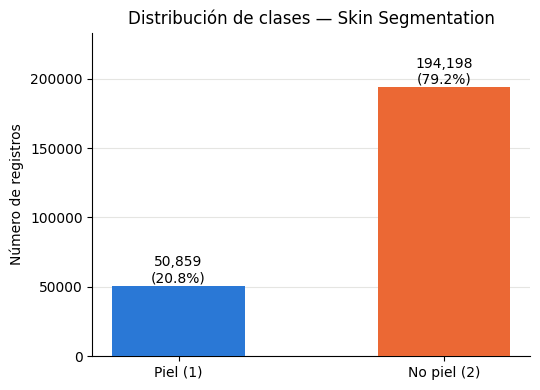

In [7]:
def plot_class_distribution(counts: pd.Series, label_names: dict) -> None:
    """Grafica la distribución de clases del atributo objetivo.

    Args:
        counts (pd.Series): Conteo de ejemplos por clase (índice = clase).
        label_names (dict): Mapeo de valor de clase a nombre legible.
    """
    counts = counts.sort_index()
    labels = [label_names[c] for c in counts.index]
    colors = [COLOR_A if c == POS_LABEL else COLOR_B for c in counts.index]

    fig, ax = plt.subplots(figsize=(5.5, 4))
    bars = ax.bar(labels, counts.values, color=colors, width=0.5, zorder=3)

    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count:,}\n({count / total:.1%})",
            ha="center", va="bottom", fontsize=10,
        )

    ax.set_ylabel("Número de registros")
    ax.set_title("Distribución de clases — Skin Segmentation")
    ax.set_ylim(0, counts.max() * 1.2)
    style_axes(ax)
    plt.tight_layout()
    plt.show()


plot_class_distribution(class_counts, LABEL_NAMES)


In [8]:
# Se deja el atributo objetivo como arreglo 1D para trabajar con
# scikit-learn (StratifiedKFold, StratifiedShuffleSplit, métricas, etc.)
y_flat = y.iloc[:, 0].to_numpy()

assert set(np.unique(y_flat)) == {POS_LABEL, NEG_LABEL}, "Etiquetas inesperadas en el atributo objetivo"


## 4. Construcción del modelo (regresión logística)

Se define un *pipeline* que encadena un escalado (`StandardScaler`) con la
regresión logística. El escalado se incluye **dentro** del pipeline —y no
se aplica antes de dividir los datos— para que, en cada partición de
entrenamiento/prueba de los esquemas de validación, la media y la
desviación estándar se calculen únicamente con los datos de entrenamiento
de esa partición, evitando fuga de información hacia el conjunto de
prueba.

In [9]:
def build_pipeline() -> Pipeline:
    """Crea el pipeline de preprocesamiento + modelo de regresión logística.

    Returns:
        Pipeline: Pipeline de scikit-learn sin entrenar.
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])


## 5. Función de evaluación

A partir de las predicciones de un modelo se calcula la matriz de
confusión y las métricas pedidas, siguiendo las definiciones de las
Secciones 11.1 a 11.3 de la lectura: **accuracy**, **sensitivity/recall**,
**specificity**, **precision** y **F1-score**. Se toma `POS_LABEL` (piel)
como clase positiva.

In [10]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Calcula la matriz de confusión y las métricas de desempeño de un modelo.

    Args:
        y_true (np.ndarray): Clase real.
        y_pred (np.ndarray): Clase predicha por el modelo.

    Returns:
        dict: Componentes de la matriz de confusión (tn, fp, fn, tp) y las
            métricas accuracy, sensitivity, specificity, precision y
            f1_score.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[NEG_LABEL, POS_LABEL]).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)  # = Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)

    return {
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1_score": f1,
    }


In [11]:
def confusion_matrix_df(tn: int, fp: int, fn: int, tp: int) -> pd.DataFrame:
    """Arma una matriz de confusión legible a partir de sus 4 componentes.

    Args:
        tn (int): Verdaderos negativos.
        fp (int): Falsos positivos.
        fn (int): Falsos negativos.
        tp (int): Verdaderos positivos.

    Returns:
        pd.DataFrame: Matriz de confusión 2x2 con etiquetas legibles.
    """
    return pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=[f"Real: {LABEL_NAMES[NEG_LABEL]}", f"Real: {LABEL_NAMES[POS_LABEL]}"],
        columns=[f"Predicho: {LABEL_NAMES[NEG_LABEL]}", f"Predicho: {LABEL_NAMES[POS_LABEL]}"],
    )


def summarize_results(
    results: pd.DataFrame,
    metric_cols=("accuracy", "sensitivity", "specificity", "precision", "f1_score"),
) -> pd.DataFrame:
    """Resume un conjunto de resultados de validación con media y desviación estándar.

    Args:
        results (pd.DataFrame): Una fila por corrida (fold o repetición),
            con las métricas como columnas.
        metric_cols (tuple): Columnas de métricas a resumir.

    Returns:
        pd.DataFrame: Media y desviación estándar por métrica.
    """
    summary = results[list(metric_cols)].agg(["mean", "std"]).T
    summary.columns = ["media", "desviación_estándar"]
    return summary


In [12]:
def plot_confusion_matrix_heatmap(tn: int, fp: int, fn: int, tp: int, title: str) -> None:
    """Grafica una matriz de confusión 2x2 como mapa de calor.

    Args:
        tn (int): Verdaderos negativos.
        fp (int): Falsos positivos.
        fn (int): Falsos negativos.
        tp (int): Verdaderos positivos.
        title (str): Título de la gráfica.
    """
    matrix = np.array([[tn, fp], [fn, tp]])
    labels = [LABEL_NAMES[NEG_LABEL], LABEL_NAMES[POS_LABEL]]

    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(matrix, cmap=SEQUENTIAL_BLUE, vmin=0)

    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_title(title)

    threshold = matrix.max() / 2
    for i in range(2):
        for j in range(2):
            value = matrix[i, j]
            color = "white" if value > threshold else "#0b0b0b"
            ax.text(j, i, f"{value:,.0f}", ha="center", va="center", color=color, fontsize=12, fontweight="bold")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Número de registros")
    plt.tight_layout()
    plt.show()


## 6. Esquema de validación 1: N-fold cross-validation (N=10)

Siguiendo la Sección 11.5.3, el conjunto de datos se divide en 10 *folds*
**estratificados** (cada fold conserva aproximadamente la misma proporción
de piel/no piel que el conjunto completo). En cada una de las 10 corridas
se entrena con 9 folds y se evalúa con el fold restante, de modo que cada
ejemplo se usa exactamente una vez como dato de prueba.

In [13]:
def run_kfold_cv(X: pd.DataFrame, y: np.ndarray, n_splits: int = 10) -> pd.DataFrame:
    """Evalúa el modelo con validación cruzada estratificada de N folds.

    Args:
        X (pd.DataFrame): Atributos de entrada.
        y (np.ndarray): Clase objetivo.
        n_splits (int): Número de folds (N).

    Returns:
        pd.DataFrame: Una fila por fold con sus métricas de desempeño.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    results = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_pipeline()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = compute_metrics(y_test, y_pred)
        metrics["fold"] = fold
        results.append(metrics)

    return pd.DataFrame(results).set_index("fold")


In [14]:
kfold_results = run_kfold_cv(X, y_flat, n_splits=N_FOLDS)
kfold_results


,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,f1_score
fold,,,,,,,,,
1,18322,1098,934,4152,0.917082,0.816359,0.943460,0.790857,0.803406
2,18265,1155,896,4190,0.916306,0.823830,0.940525,0.783910,0.803375
3,18284,1136,859,4227,0.918591,0.831105,0.941504,0.788178,0.809073
4,18315,1105,893,4193,0.918469,0.824420,0.943100,0.791431,0.807589
5,18279,1141,857,4229,0.918469,0.831498,0.941246,0.787523,0.808914
6,18369,1051,943,4143,0.918632,0.814589,0.945881,0.797651,0.806031
7,18377,1043,913,4173,0.920183,0.820488,0.946292,0.800038,0.810134
8,18344,1075,875,4211,0.920424,0.827959,0.944642,0.796633,0.811994
9,18358,1061,912,4174,0.919486,0.820684,0.945363,0.797326,0.808836


In [15]:
kfold_summary = summarize_results(kfold_results)
print(f"Resumen — Validación cruzada de {N_FOLDS} folds:")
kfold_summary


Resumen — Validación cruzada de 10 folds:


,media,desviación_estándar
accuracy,0.918778,0.001345
sensitivity,0.823473,0.005678
specificity,0.943738,0.002088
precision,0.793145,0.005476
f1_score,0.807999,0.002920


In [16]:
# Como los folds son disjuntos y cubren todo el dataset exactamente una vez,
# sumar los conteos de los 10 folds equivale a la matriz de confusión sobre
# el conjunto de datos completo.
kfold_totals = kfold_results[["tn", "fp", "fn", "tp"]].sum()
print("Matriz de confusión agregada (suma de los 10 folds):")
confusion_matrix_df(kfold_totals["tn"], kfold_totals["fp"], kfold_totals["fn"], kfold_totals["tp"])


Matriz de confusión agregada (suma de los 10 folds):


,Predicho: No piel (2),Predicho: Piel (1)
Real: No piel (2),183272,10926
Real: Piel (1),8978,41881


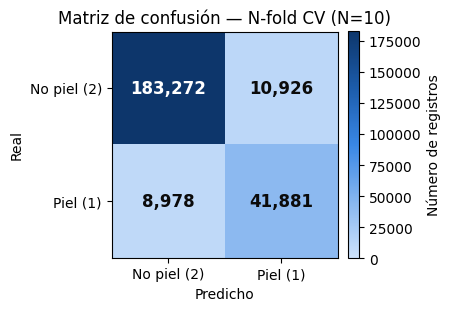

In [17]:
plot_confusion_matrix_heatmap(
    kfold_totals["tn"], kfold_totals["fp"], kfold_totals["fn"], kfold_totals["tp"],
    title=f"Matriz de confusión — N-fold CV (N={N_FOLDS})",
)


## 7. Esquema de validación 2: random subsampling (70/30, 10 repeticiones)

Siguiendo la Sección 11.5.2, se repite 10 veces una partición aleatoria
**estratificada** en 70% entrenamiento / 30% prueba. Las particiones son
independientes entre sí (cada repetición vuelve a mezclar y dividir el
dataset), y al final se reporta la media y desviación estándar de cada
métrica sobre las 10 corridas.

In [18]:
def run_random_subsampling(
    X: pd.DataFrame, y: np.ndarray, n_repeats: int = 10, test_size: float = 0.3
) -> pd.DataFrame:
    """Evalúa el modelo con random subsampling (particiones train/test repetidas).

    Args:
        X (pd.DataFrame): Atributos de entrada.
        y (np.ndarray): Clase objetivo.
        n_repeats (int): Número de repeticiones.
        test_size (float): Proporción del conjunto de prueba en cada repetición.

    Returns:
        pd.DataFrame: Una fila por repetición con sus métricas de desempeño.
    """
    sss = StratifiedShuffleSplit(n_splits=n_repeats, test_size=test_size, random_state=RANDOM_STATE)
    results = []

    for rep, (train_idx, test_idx) in enumerate(sss.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_pipeline()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = compute_metrics(y_test, y_pred)
        metrics["repeticion"] = rep
        results.append(metrics)

    return pd.DataFrame(results).set_index("repeticion")


In [19]:
subsampling_results = run_random_subsampling(X, y_flat, n_repeats=N_REPEATS, test_size=TEST_SIZE)
subsampling_results


,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,f1_score
repeticion,,,,,,,,,
1,54909,3351,2691,12567,0.917816,0.823634,0.942482,0.789484,0.806197
2,54954,3306,2722,12536,0.918006,0.821602,0.943254,0.791314,0.806174
3,54916,3344,2677,12581,0.918102,0.824551,0.942602,0.790016,0.806914
4,54871,3389,2684,12574,0.917394,0.824092,0.941830,0.787697,0.805483
5,54984,3276,2721,12537,0.918428,0.821667,0.943769,0.792829,0.806990
6,54985,3275,2642,12616,0.919516,0.826845,0.943786,0.793909,0.810042
7,55001,3259,2675,12583,0.919285,0.824682,0.944061,0.794281,0.809196
8,55008,3252,2721,12537,0.918755,0.821667,0.944181,0.794034,0.807614
9,54980,3280,2635,12623,0.919544,0.827304,0.943701,0.793750,0.810179


In [20]:
subsampling_summary = summarize_results(subsampling_results)
print(f"Resumen — Random subsampling ({int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}, {N_REPEATS} repeticiones):")
subsampling_summary


Resumen — Random subsampling (70/30, 10 repeticiones):


,media,desviación_estándar
accuracy,0.918525,0.000738
sensitivity,0.824269,0.002182
specificity,0.943210,0.000814
precision,0.791725,0.002345
f1_score,0.807667,0.001651


In [21]:
# A diferencia de N-fold CV, los conjuntos de prueba de las repeticiones se
# pueden solapar, por lo que aquí se reporta el promedio (redondeado) de la
# matriz de confusión por repetición, en vez de la suma.
subsampling_avg = subsampling_results[["tn", "fp", "fn", "tp"]].mean().round(0).astype(int)
print("Matriz de confusión promedio por repetición:")
confusion_matrix_df(subsampling_avg["tn"], subsampling_avg["fp"], subsampling_avg["fn"], subsampling_avg["tp"])


Matriz de confusión promedio por repetición:


,Predicho: No piel (2),Predicho: Piel (1)
Real: No piel (2),54951,3309
Real: Piel (1),2681,12577


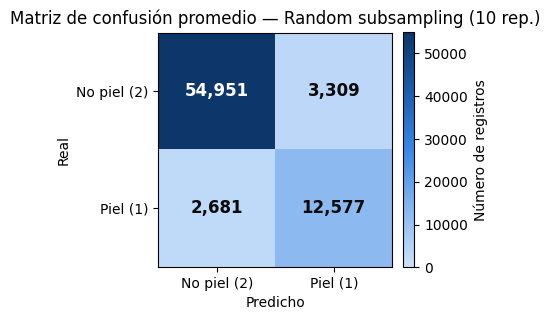

In [22]:
plot_confusion_matrix_heatmap(
    subsampling_avg["tn"], subsampling_avg["fp"], subsampling_avg["fn"], subsampling_avg["tp"],
    title=f"Matriz de confusión promedio — Random subsampling ({N_REPEATS} rep.)",
)


## 8. Comparación de los dos esquemas de evaluación

In [23]:
comparison = pd.concat(
    {
        f"N-fold CV (N={N_FOLDS})": kfold_summary["media"],
        f"Random subsampling ({int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}, {N_REPEATS} rep.)": subsampling_summary["media"],
    },
    axis=1,
)
comparison


,N-fold CV (N=10),"Random subsampling (70/30, 10 rep.)"
accuracy,0.918778,0.918525
sensitivity,0.823473,0.824269
specificity,0.943738,0.943210
precision,0.793145,0.791725
f1_score,0.807999,0.807667


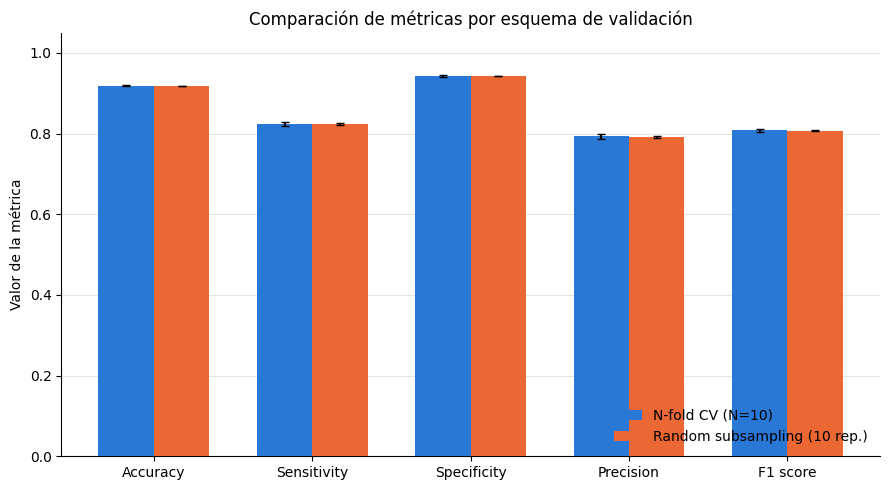

In [24]:
def plot_metric_comparison(kfold_summary: pd.DataFrame, subsampling_summary: pd.DataFrame) -> None:
    """Grafica, para cada métrica, la media (± desviación estándar) de cada esquema.

    Args:
        kfold_summary (pd.DataFrame): Resumen (media, desviación_estándar) de N-fold CV.
        subsampling_summary (pd.DataFrame): Resumen (media, desviación_estándar) de random subsampling.
    """
    metrics = list(kfold_summary.index)
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(
        x - width / 2, kfold_summary["media"], width,
        yerr=kfold_summary["desviación_estándar"], capsize=3,
        label=f"N-fold CV (N={N_FOLDS})", color=COLOR_A, zorder=3,
    )
    ax.bar(
        x + width / 2, subsampling_summary["media"], width,
        yerr=subsampling_summary["desviación_estándar"], capsize=3,
        label=f"Random subsampling ({N_REPEATS} rep.)", color=COLOR_B, zorder=3,
    )

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("_", " ").capitalize() for m in metrics])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Valor de la métrica")
    ax.set_title("Comparación de métricas por esquema de validación")
    ax.legend(frameon=False, loc="lower right")
    style_axes(ax)
    plt.tight_layout()
    plt.show()


plot_metric_comparison(kfold_summary, subsampling_summary)


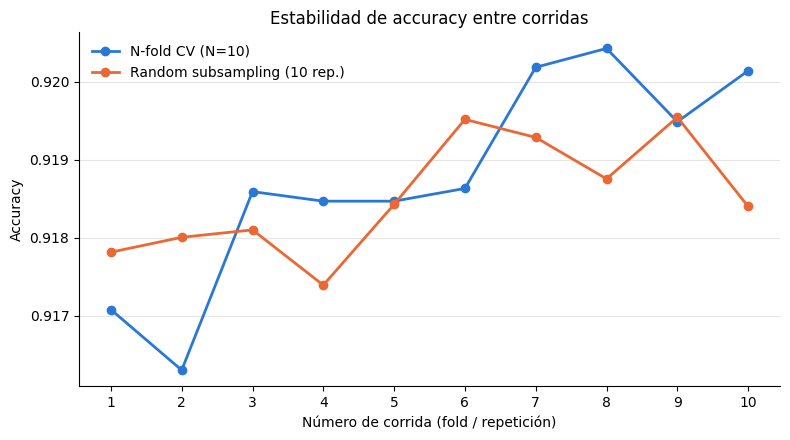

In [25]:
def plot_metric_stability(kfold_results: pd.DataFrame, subsampling_results: pd.DataFrame, metric: str = "accuracy") -> None:
    """Grafica el valor de una métrica corrida por corrida, para ver qué tan estable es.

    Args:
        kfold_results (pd.DataFrame): Resultados por fold de N-fold CV.
        subsampling_results (pd.DataFrame): Resultados por repetición de random subsampling.
        metric (str): Nombre de la métrica a graficar.
    """
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(
        kfold_results.index, kfold_results[metric], marker="o", linewidth=2,
        color=COLOR_A, label=f"N-fold CV (N={N_FOLDS})",
    )
    ax.plot(
        subsampling_results.index, subsampling_results[metric], marker="o", linewidth=2,
        color=COLOR_B, label=f"Random subsampling ({N_REPEATS} rep.)",
    )

    ax.set_xlabel("Número de corrida (fold / repetición)")
    ax.set_ylabel(metric.replace("_", " ").capitalize())
    ax.set_title(f"Estabilidad de {metric.replace('_', ' ')} entre corridas")
    ax.set_xticks(range(1, max(N_FOLDS, N_REPEATS) + 1))
    ax.legend(frameon=False)
    style_axes(ax)
    plt.tight_layout()
    plt.show()


plot_metric_stability(kfold_results, subsampling_results, metric="accuracy")


In [26]:
best_scheme = comparison.loc["f1_score"].idxmax()

print(
    "Resumen de la comparación:\n"
    f"- N-fold CV (N={N_FOLDS}): accuracy = {kfold_summary.loc['accuracy', 'media']:.4f} "
    f"± {kfold_summary.loc['accuracy', 'desviación_estándar']:.4f}, "
    f"F1-score = {kfold_summary.loc['f1_score', 'media']:.4f} "
    f"± {kfold_summary.loc['f1_score', 'desviación_estándar']:.4f}\n"
    f"- Random subsampling: accuracy = {subsampling_summary.loc['accuracy', 'media']:.4f} "
    f"± {subsampling_summary.loc['accuracy', 'desviación_estándar']:.4f}, "
    f"F1-score = {subsampling_summary.loc['f1_score', 'media']:.4f} "
    f"± {subsampling_summary.loc['f1_score', 'desviación_estándar']:.4f}\n"
    f"- Esquema con mayor F1-score promedio: {best_scheme}"
)


Resumen de la comparación:
- N-fold CV (N=10): accuracy = 0.9188 ± 0.0013, F1-score = 0.8080 ± 0.0029
- Random subsampling: accuracy = 0.9185 ± 0.0007, F1-score = 0.8077 ± 0.0017
- Esquema con mayor F1-score promedio: N-fold CV (N=10)


## 9. Análisis de los resultados obtenidos

**Sobre el funcionamiento del modelo**

Skin Segmentation es un problema relativamente sencillo para un modelo lineal
como la regresión logística: solo tiene 3 atributos numéricos (B, G, R) y las
clases piel/no piel tienden a ser bastante separables en el espacio de color,
por lo que se espera un desempeño alto y consistente en accuracy, sensitivity,
specificity, precision y F1-score, en los dos esquemas de validación. Como el
dataset está desbalanceado (~21% piel / ~79% no piel, Sección 11.2), vale la
pena revisar sensitivity y specificity y no quedarse solo con accuracy: una
sensitivity baja indicaría que el modelo está dejando pasar píxeles de piel
como si fueran fondo, que en una aplicación real (por ejemplo, detección de
piel en imágenes) suele ser un error más costoso que el contrario.

**Sobre el esquema de validación más adecuado**

Con 245.057 registros, tanto N-fold CV (N=10, folds de ~24.500 registros) como
random subsampling (70/30, particiones de prueba de ~73.500 registros, 10
repeticiones) trabajan con conjuntos de prueba grandes, así que ambos deberían
dar estimaciones estables y con poca variación entre corridas (desviación
estándar baja, visible en la gráfica de estabilidad de la Sección 8). Aun así,
para este caso preferimos **N-fold cross-validation**: al ser los folds
disjuntos, cada registro se usa exactamente una vez como dato de prueba y,
entre las 10 corridas, el modelo termina evaluándose sobre el 100% del dataset
(Sección 11.5.3). Random subsampling, en cambio, puede repetir registros entre
repeticiones y no garantiza cubrir todo el dataset. Con un conjunto de datos
de este tamaño no hay necesidad de recurrir a random subsampling solo para
tener más observaciones de evaluación — su principal ventaja (poder ajustar
libremente el tamaño de la partición) no compensa aquí la garantía de
cobertura completa que da N-fold CV.

Los valores concretos de cada métrica quedan en las tablas y gráficas de las
Secciones 6 a 8; si al ejecutar el notebook las métricas de ambos esquemas
resultan prácticamente iguales entre sí, es una señal adicional de que el
modelo es estable frente a la partición de los datos usada.